In [1]:
!pip -q install diffrax optax matplotlib

In [2]:
import time

import diffrax as dfx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax

print("JAX", jax.__version__)
print("Devices:", jax.devices())

TRUE_ZETA = 0.15
TRUE_OMEGA = 2.0
T0, T1 = 0.0, 6.0


def oscillator_rhs(t, y, args):
    zeta, omega = args
    x, v = y
    return jnp.array([v, -2.0 * zeta * omega * v - (omega ** 2) * x], dtype=jnp.float32)


def solve_single(ts, y0, zeta, omega):
    term = dfx.ODETerm(oscillator_rhs)
    solver = dfx.Tsit5()
    controller = dfx.PIDController(rtol=1e-5, atol=1e-7)
    sol = dfx.diffeqsolve(
        term,
        solver,
        t0=ts[0],
        t1=ts[-1],
        dt0=ts[1] - ts[0],
        y0=y0,
        args=(zeta, omega),
        saveat=dfx.SaveAt(ts=ts),
        stepsize_controller=controller,
        max_steps=4096,
    )
    return sol.ys


simulate_batch = jax.jit(jax.vmap(solve_single, in_axes=(None, 0, None, None)))


def raw_to_params(raw):
    zeta = jax.nn.sigmoid(raw[0])
    omega = jax.nn.softplus(raw[1]) + 0.1
    return zeta, omega


def sample_initial_states(key, num_trajectories):
    key_x, key_v = jr.split(key)
    x0 = jr.uniform(key_x, (num_trajectories,), minval=0.5, maxval=1.5)
    v0 = jr.uniform(key_v, (num_trajectories,), minval=-0.5, maxval=0.5)
    return jnp.stack([x0, v0], axis=-1)


def make_dataset(seed, noise_std, num_points, num_trajectories, zeta_true=TRUE_ZETA, omega_true=TRUE_OMEGA):
    key = jr.PRNGKey(seed)
    key_init, key_noise = jr.split(key)
    ts = jnp.linspace(T0, T1, num_points, dtype=jnp.float32)
    y0s = sample_initial_states(key_init, num_trajectories)
    true_states = simulate_batch(ts, y0s, jnp.array(zeta_true), jnp.array(omega_true))
    true_x = true_states[..., 0]
    observed_x = true_x + noise_std * jr.normal(key_noise, true_x.shape)
    return ts, y0s, true_x, observed_x


def make_holdout_dataset(seed, num_points, num_trajectories, zeta_true=TRUE_ZETA, omega_true=TRUE_OMEGA):
    key = jr.PRNGKey(seed)
    ts = jnp.linspace(T0, T1, num_points, dtype=jnp.float32)
    y0s = sample_initial_states(key, num_trajectories)
    true_states = simulate_batch(ts, y0s, jnp.array(zeta_true), jnp.array(omega_true))
    return ts, y0s, true_states[..., 0]


def loss_fn(raw, ts, y0s, observed_x):
    zeta, omega = raw_to_params(raw)
    pred_x = simulate_batch(ts, y0s, zeta, omega)[..., 0]
    return jnp.mean((pred_x - observed_x) ** 2)


def make_train_step(optimizer):
    @jax.jit
    def step(raw, opt_state, ts, y0s, observed_x):
        loss, grads = jax.value_and_grad(loss_fn)(raw, ts, y0s, observed_x)
        updates, opt_state = optimizer.update(grads, opt_state, raw)
        raw = optax.apply_updates(raw, updates)
        return raw, opt_state, loss
    return step


def fit_case(
    seed=0,
    noise_std=0.03,
    num_points=50,
    num_trajectories=4,
    num_test_trajectories=8,
    steps=250,
    learning_rate=0.05,
):
    ts, y0s, true_x, observed_x = make_dataset(
        seed=seed,
        noise_std=noise_std,
        num_points=num_points,
        num_trajectories=num_trajectories,
    )

    optimizer = optax.adam(learning_rate)
    step_fn = make_train_step(optimizer)
    raw = jnp.array([0.0, 0.0], dtype=jnp.float32)
    opt_state = optimizer.init(raw)

    history = []
    start = time.perf_counter()
    for _ in range(steps):
        raw, opt_state, loss = step_fn(raw, opt_state, ts, y0s, observed_x)
        history.append(float(loss))
    jax.block_until_ready(raw)
    fit_time_s = time.perf_counter() - start

    zeta_hat, omega_hat = raw_to_params(raw)
    pred_x = simulate_batch(ts, y0s, zeta_hat, omega_hat)[..., 0]
    jax.block_until_ready(pred_x)

    heldout_ts, heldout_y0s, heldout_true_x = make_holdout_dataset(
        seed=seed + 10_000,
        num_points=num_points,
        num_trajectories=num_test_trajectories,
    )
    heldout_pred_x = simulate_batch(heldout_ts, heldout_y0s, zeta_hat, omega_hat)[..., 0]
    jax.block_until_ready(heldout_pred_x)

    zeta_hat = float(zeta_hat)
    omega_hat = float(omega_hat)
    zeta_error = abs(zeta_hat - TRUE_ZETA)
    omega_error = abs(omega_hat - TRUE_OMEGA)
    combined_rel_error = 0.5 * (
        zeta_error / TRUE_ZETA + omega_error / TRUE_OMEGA
    )
    trajectory_mse = float(jnp.mean((pred_x - observed_x) ** 2))
    heldout_mse = float(jnp.mean((heldout_pred_x - heldout_true_x) ** 2))

    return {
        "seed": seed,
        "noise_std": noise_std,
        "num_points": num_points,
        "zeta_hat": zeta_hat,
        "omega_hat": omega_hat,
        "zeta_error": zeta_error,
        "omega_error": omega_error,
        "combined_rel_error": combined_rel_error,
        "trajectory_mse": trajectory_mse,
        "heldout_mse": heldout_mse,
        "fit_time_s": fit_time_s,
        "ts": np.asarray(ts),
        "true_x": np.asarray(true_x),
        "observed_x": np.asarray(observed_x),
        "predicted_x": np.asarray(pred_x),
        "heldout_ts": np.asarray(heldout_ts),
        "heldout_true_x": np.asarray(heldout_true_x),
        "heldout_predicted_x": np.asarray(heldout_pred_x),
        "history": np.asarray(history),
    }


def print_summary(results, noise_levels, point_counts):
    print("\nMedian across seeds")
    print("noise_std | num_points | zeta_err | omega_err | rel_err | train_mse | heldout_mse | fit_time_s")
    print("-" * 98)
    for noise in noise_levels:
        for points in point_counts:
            subset = [r for r in results if r["noise_std"] == noise and r["num_points"] == points]
            zeta_err = np.median([r["zeta_error"] for r in subset])
            omega_err = np.median([r["omega_error"] for r in subset])
            rel_err = np.median([r["combined_rel_error"] for r in subset])
            train_mse = np.median([r["trajectory_mse"] for r in subset])
            heldout_mse = np.median([r["heldout_mse"] for r in subset])
            fit_time = np.median([r["fit_time_s"] for r in subset])
            print(
                f"{noise:8.3f} | {points:10d} | {zeta_err:8.4f} | {omega_err:9.4f} | "
                f"{rel_err:7.4f} | {train_mse:9.6f} | {heldout_mse:11.6f} | {fit_time:10.3f}"
            )


def plot_single_fit(result):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(result["history"])
    axes[0].set_title("Optimization loss")
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("MSE")

    axes[1].plot(result["ts"], result["true_x"][0], label="True", linewidth=2)
    axes[1].scatter(result["ts"], result["observed_x"][0], label="Observed", s=12, alpha=0.7)
    axes[1].plot(result["ts"], result["predicted_x"][0], label="Recovered", linewidth=2)
    axes[1].set_title("Training trajectory")
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("Position")
    axes[1].legend()

    axes[2].plot(result["heldout_ts"], result["heldout_true_x"][0], label="True", linewidth=2)
    axes[2].plot(result["heldout_ts"], result["heldout_predicted_x"][0], label="Recovered", linewidth=2)
    axes[2].set_title("Held-out trajectory")
    axes[2].set_xlabel("Time")
    axes[2].set_ylabel("Position")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


JAX 0.7.2
Devices: [CudaDevice(id=0)]


true zeta=0.1500  true omega=2.0000
hat  zeta=0.1495  hat  omega=1.9994
zeta error=0.000463
omega error=0.000633
combined relative error=0.001703
train trajectory mse=0.000841
held-out trajectory mse=0.000001
fit time=22.578s


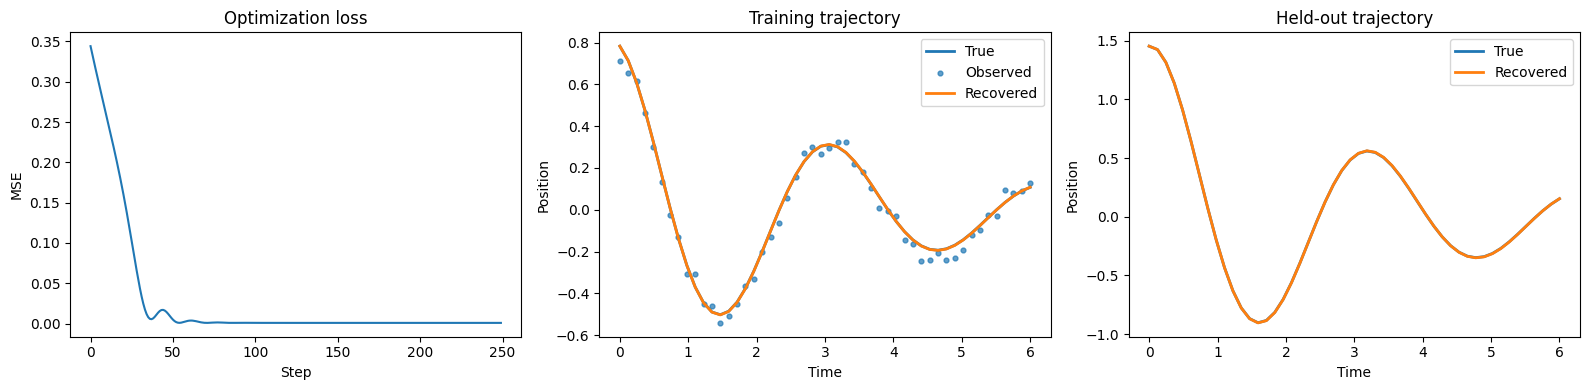

In [3]:
single = fit_case(
    seed=0,
    noise_std=0.03,
    num_points=50,
    num_trajectories=4,
    num_test_trajectories=8,
    steps=250,
    learning_rate=0.05,
)

print(f"true zeta={TRUE_ZETA:.4f}  true omega={TRUE_OMEGA:.4f}")
print(f"hat  zeta={single['zeta_hat']:.4f}  hat  omega={single['omega_hat']:.4f}")
print(f"zeta error={single['zeta_error']:.6f}")
print(f"omega error={single['omega_error']:.6f}")
print(f"combined relative error={single['combined_rel_error']:.6f}")
print(f"train trajectory mse={single['trajectory_mse']:.6f}")
print(f"held-out trajectory mse={single['heldout_mse']:.6f}")
print(f"fit time={single['fit_time_s']:.3f}s")

plot_single_fit(single)


In [4]:
noise_levels = [0.03, 0.1]
point_counts = [20, 50]
seeds = [0, 1, 2]

results = []
total = len(noise_levels) * len(point_counts) * len(seeds)
idx = 0

for points in point_counts:
    for noise in noise_levels:
        for seed in seeds:
            idx += 1
            print(f"[{idx}/{total}] seed={seed} noise={noise:.3f} num_points={points}", flush=True)
            result = fit_case(
                seed=seed,
                noise_std=noise,
                num_points=points,
                num_trajectories=4,
                num_test_trajectories=8,
                steps=200,
                learning_rate=0.05,
            )
            print(
                f"  zeta_hat={result['zeta_hat']:.4f} "
                f"omega_hat={result['omega_hat']:.4f} "
                f"rel_err={result['combined_rel_error']:.4f} "
                f"train_mse={result['trajectory_mse']:.6f} "
                f"heldout_mse={result['heldout_mse']:.6f} "
                f"time={result['fit_time_s']:.2f}s",
                flush=True,
            )
            results.append(result)

print_summary(results, noise_levels, point_counts)


[1/12] seed=0 noise=0.030 num_points=20
  zeta_hat=0.1493 omega_hat=1.9977 rel_err=0.0028 train_mse=0.001045 heldout_mse=0.000005 time=19.48s
[2/12] seed=1 noise=0.030 num_points=20
  zeta_hat=0.1480 omega_hat=1.9962 rel_err=0.0076 train_mse=0.000892 heldout_mse=0.000016 time=15.33s
[3/12] seed=2 noise=0.030 num_points=20
  zeta_hat=0.1548 omega_hat=2.0063 rel_err=0.0175 train_mse=0.000977 heldout_mse=0.000052 time=15.22s
[4/12] seed=0 noise=0.100 num_points=20
  zeta_hat=0.1477 omega_hat=1.9923 rel_err=0.0097 train_mse=0.011613 heldout_mse=0.000051 time=15.13s
[5/12] seed=1 noise=0.100 num_points=20
  zeta_hat=0.1433 omega_hat=1.9875 rel_err=0.0256 train_mse=0.009906 heldout_mse=0.000188 time=15.23s
[6/12] seed=2 noise=0.100 num_points=20
  zeta_hat=0.1663 omega_hat=2.0226 rel_err=0.0601 train_mse=0.010860 heldout_mse=0.000578 time=15.13s
[7/12] seed=0 noise=0.030 num_points=50
  zeta_hat=0.1495 omega_hat=1.9993 rel_err=0.0017 train_mse=0.000841 heldout_mse=0.000001 time=15.76s
[8/12]